# Step 9. Integrated Walk-Forward Dynamic Backtest

**목적**: 경로 1(일별 경보→주식 축소) + 경로 2(레짐 기반 Σ 전환)를 **MV baseline 위에 통합**한 Walk-Forward 동적 백테스트.

**4개 모드 비교 설계** (경로 기여도 분해용):

| 모드 | Baseline | 경로 1 (일별 경보) | 경로 2 (월별 Σ) | 의미 |
|------|---------|------------------|----------------|-----|
| **M0** | MV (Σ_all) | ❌ | ❌ | 순수 MV (Step4 재현) |
| **M1** | MV (Σ_all) | ✅ | ❌ | 경로 1만 추가 |
| **M2** | MV (Σ_stable 또는 Σ_crisis, **월별 전환**) | ❌ | ✅ | 경로 2만 추가 |
| **M3** | MV (Σ_stable 또는 Σ_crisis, **월별 전환**) | ✅ | ✅ | **통합 (최종 제안)** |

**v4.1 개선**: 경로 2를 OOS 시작일 1회 → **OOS 월 단위 재전환**으로 변경. intra-quarter 레짐 변화 포착.

**시뮬레이션 규모 (효율화 적용)**:
- M0: 4 성향 × 1 (Config 무관) = **4개 실행** → 4 Config에 복제 저장
- M1/M2/M3: 3 모드 × 4 성향 × 4 Config = **48개 실행**
- 실제 실행: **52개** (기존 64 대비 19% 절감)
- 저장 키: 64개 + 벤치마크 3개 = **67개 전략**

**목차**:
- 9-1. 4개 모드 시뮬레이션 함수 정의
- 9-2. 64개 시뮬레이션 실행
- 9-3. 벤치마크 3개 실행
- 9-4. 성과 지표 계산 및 순위 테이블
- 9-5. 시각화
- 9-6. 산출물 저장

**입력**:
- `data/portfolio_prices.csv`, `data/alert_signals.csv`, `data/profiles.csv`
- `data/regime_covariance_by_window.pkl` (Step8)

**산출물**:
- `data/step9_backtest_results.pkl`
- `data/step9_metrics.csv`
- `images/step9_*.png` (4개)


In [1]:
# ============================================================
# 라이브러리 임포트 + 한글 폰트 설정
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import os
import platform
import warnings
import time
from pathlib import Path

from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (CLAUDE.md 지침 준수)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import koreanize_matplotlib  # noqa: F401
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 경로 설정
DATA_DIR = Path('data')
IMG_DIR = Path('images')
DATA_DIR.mkdir(exist_ok=True)
IMG_DIR.mkdir(exist_ok=True)

print('Step 9 라이브러리 임포트 완료')


Step 9 라이브러리 임포트 완료


In [2]:
# ============================================================
# 데이터 로드
# ============================================================

# 기본 데이터
prices = pd.read_csv(DATA_DIR / 'portfolio_prices.csv',
                     parse_dates=['Date'], index_col='Date')
alerts = pd.read_csv(DATA_DIR / 'alert_signals.csv',
                     parse_dates=['Date'], index_col='Date')
profiles_df = pd.read_csv(DATA_DIR / 'profiles.csv')

# Step8 산출물: Σ_stable, Σ_crisis
with open(DATA_DIR / 'regime_covariance_by_window.pkl', 'rb') as f:
    step8_data = pickle.load(f)

windows_cov = step8_data['windows']
STABLE_REGIMES = step8_data['stable_regimes']
CRISIS_REGIMES = step8_data['crisis_regimes']

# 수익률 (산술 수익률 = 가격 변화율 — 일별 합산·비교 편의)
asset_returns = prices.pct_change().dropna().loc['2016-01-01':]  # ANALYSIS_START (2026-04-19)
# 로그 수익률 (추정용)
log_returns = np.log(prices / prices.shift(1)).dropna().loc['2016-01-01':]  # ANALYSIS_START (2026-04-19)

print(f'가격 데이터: {prices.shape}')
print(f'경보 신호: {alerts.shape}, 컬럼: {list(alerts.columns)[:6]}')
print(f'투자자 성향: {profiles_df.shape}')
print(f'Step8 윈도우 수: {len(windows_cov)}')
print(f'Stable regimes: {STABLE_REGIMES}, Crisis regimes: {CRISIS_REGIMES}')


가격 데이터: (3017, 30)
경보 신호: (2491, 10), 컬럼: ['alert_a', 'alert_b', 'alert_c', 'alert_d', 'stress_score', 'VIX_level']
투자자 성향: (4, 9)
Step8 윈도우 수: 31
Stable regimes: [0, 1], Crisis regimes: [2, 3]


In [3]:
# ============================================================
# 공통 설정: 자산 그룹, 경보 감축률, 거래비용
# ============================================================

PORT_TICKERS = list(prices.columns)

# 자산 그룹 인덱스 (Step7과 동일)
EQUITY_BROAD  = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
EQUITY_SECTOR = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX',
                 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
EQUITY_SINGLE = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']
EQUITY_ALL    = EQUITY_BROAD + EQUITY_SECTOR + EQUITY_SINGLE
BOND          = ['TLT', 'AGG', 'SHY', 'TIP']
GOLD_ALT      = ['GLD', 'DBC']

EQUITY_IDX = [PORT_TICKERS.index(t) for t in EQUITY_ALL]
BOND_IDX   = [PORT_TICKERS.index(t) for t in BOND]
GOLD_IDX   = [PORT_TICKERS.index(t) for t in GOLD_ALT]

# 성향별 EQUITY_CUT 테이블 (Step7과 동일)
EQUITY_CUT = {
    '보수형': {0: 0.00, 1: 0.15, 2: 0.35, 3: 0.60},
    '중립형': {0: 0.00, 1: 0.10, 2: 0.25, 3: 0.50},
    '적극형': {0: 0.00, 1: 0.05, 2: 0.15, 3: 0.35},
    '공격형': {0: 0.00, 1: 0.00, 2: 0.10, 3: 0.25},
}

# 거래비용: 매수·매도 총합(turnover = Σ|Δw|)에 15bps 적용
# turnover는 이미 매수+매도 양방을 모두 포함하므로 사실상 왕복 30bps 등가
# decision_log v3 "편도 15bps" 정의에 부합 (turnover 계산법과 결합하여 실질 왕복비용)
COST_BPS   = 10
SLIP_BPS   = 5
TOTAL_COST = (COST_BPS + SLIP_BPS) / 10_000  # 15bps per turnover unit

# 성향 파라미터 맵
PROFILES = ['보수형', '중립형', '적극형', '공격형']
PROFILE_PARAMS = {}
for _, row in profiles_df.iterrows():
    PROFILE_PARAMS[row['profile']] = {
        'gamma':      row['gamma'],
        'max_equity': row['max_equity'],
        'min_bond':   row['min_bond'],
    }

# 경보 Config (Step6 산출물: alert_a/b/c/d)
ALERT_CONFIGS = {
    'ALERT_A': 'alert_a',
    'ALERT_B': 'alert_b',
    'ALERT_C': 'alert_c',
    'ALERT_D': 'alert_d',
}
CONFIG_NAMES = list(ALERT_CONFIGS.keys())

# 모드 정의
MODES = ['M0', 'M1', 'M2', 'M3']

print(f'자산: EQUITY {len(EQUITY_IDX)}개, BOND {len(BOND_IDX)}개, GOLD {len(GOLD_IDX)}개 → 총 {len(PORT_TICKERS)}')
print(f'성향: {PROFILES}')
print(f'Config: {CONFIG_NAMES}')
print(f'모드: {MODES}')
print(f'거래비용: {TOTAL_COST*10_000:.0f} bps (편도)')
print()
print(f'전체 시뮬레이션: {len(PROFILES)} × {len(CONFIG_NAMES)} × {len(MODES)} = {len(PROFILES)*len(CONFIG_NAMES)*len(MODES)}개 + 벤치마크 3개')


자산: EQUITY 24개, BOND 4개, GOLD 2개 → 총 30
성향: ['보수형', '중립형', '적극형', '공격형']
Config: ['ALERT_A', 'ALERT_B', 'ALERT_C', 'ALERT_D']
모드: ['M0', 'M1', 'M2', 'M3']
거래비용: 15 bps (편도)

전체 시뮬레이션: 4 × 4 × 4 = 64개 + 벤치마크 3개


## 9-1. 4개 모드 시뮬레이션 함수 정의

각 모드의 핵심 차이는 **Σ 선택 방식**과 **일별 경보 반영 여부** 입니다.

```
모드 결정 트리:
  Σ 선택:  M0, M1 → Σ_all (Step4 재현, 경보 무관)
           M2, M3 → OOS 월 단위로 경보 재확인 → Σ_stable 또는 Σ_crisis 전환

  일별:     M0, M2 → 일별 경보 반영 안 함 (월별 Σ 전환만)
           M1, M3 → 매일 경보 레벨 체크 → 주식 축소 (즉시 반영)
```

**경로 1 일별 리밸런싱 규칙 (v4.1 코드 동작)**:
- 매일 `alert_today` 로 `target_weights` 즉시 계산 (cut 비율 적용)
- 경보 상승 시: 주식 비중 × `cut%` 감축, 채권 70% + 금 30%로 재배분
- 경보 하락 시: **즉시 원상 복구** (점진적 복원 미구현, whipsaw 방지 필터는 Config D의 5일 debounce가 대체)
- *Note*: 기존 문서의 "3~5일 점진 복원"은 미구현이므로 코드 기준으로 서술


In [4]:
# ============================================================
# MV 최적화 함수 (Step4 로직 재사용)
# ============================================================

def optimize_mv_weights(mu, cov, profile_params, tickers, eq_idx, bd_idx):
    """
    Mean-Variance 최적화 (성향 제약 반영).

    목적함수:  max  w'μ - (γ/2) · w'Σw
    제약:      sum(w) = 1, w ≥ 0, sum(w[eq_idx]) ≤ max_equity,
               sum(w[bd_idx]) ≥ min_bond
    """
    gamma    = profile_params['gamma']
    max_eq   = profile_params['max_equity']
    min_bd   = profile_params['min_bond']
    n        = len(tickers)

    def neg_utility(w):
        ret  = w @ mu
        risk = w @ cov @ w
        return -(ret - gamma / 2 * risk)

    constraints = [
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1.0},
    ]
    if len(eq_idx) > 0:
        constraints.append({'type': 'ineq',
                            'fun': lambda w: max_eq - np.sum(w[eq_idx])})
    if len(bd_idx) > 0:
        constraints.append({'type': 'ineq',
                            'fun': lambda w: np.sum(w[bd_idx]) - min_bd})

    bounds = [(0, 1)] * n
    w0     = np.ones(n) / n

    result = minimize(neg_utility, w0, method='SLSQP',
                       bounds=bounds, constraints=constraints,
                       options={'maxiter': 500, 'ftol': 1e-10})

    if result.success:
        w = np.maximum(result.x, 0)
        w = w / w.sum()
        return w
    else:
        # 실패 시 Equal Weight fallback
        return np.ones(n) / n


print('optimize_mv_weights 함수 정의 완료')


optimize_mv_weights 함수 정의 완료


In [5]:
# ============================================================
# 통합 시뮬레이션 함수 (모드별 분기)
# ============================================================

def apply_equity_cut_vec(w_base, cut_ratio, eq_idx, bd_idx, gd_idx):
    """
    경로 1: 주식 비중을 cut_ratio만큼 감축 → 채권 70% + 금 30% 재배분.

    Parameters
    ----------
    w_base : np.ndarray - 기준 비중 벡터
    cut_ratio : float - 주식 감축률 [0, 1]
    eq_idx, bd_idx, gd_idx : list - 자산 인덱스
    """
    if cut_ratio <= 0:
        return w_base.copy()

    w = w_base.copy()
    freed = 0.0
    for i in eq_idx:
        reduction = w[i] * cut_ratio
        w[i] -= reduction
        freed += reduction

    if freed > 0 and len(bd_idx) > 0:
        per_bond = freed * 0.70 / len(bd_idx)
        for i in bd_idx:
            w[i] += per_bond
    if freed > 0 and len(gd_idx) > 0:
        per_gold = freed * 0.30 / len(gd_idx)
        for i in gd_idx:
            w[i] += per_gold

    # 정규화 (수치 안정성)
    w = np.clip(w, 0, 1)
    w = w / w.sum()
    return w


def select_cov_by_alert(w_info, alert_level, mode):
    """모드와 경보 레벨에 따라 적절한 Σ 선택."""
    if mode in ('M2', 'M3'):
        return w_info['Sigma_crisis'] if alert_level >= 2 else w_info['Sigma_stable']
    else:
        return None  # M0/M1은 별도 계산 (Σ_all)


def run_simulation(mode, profile, config_name, log_returns, asset_returns,
                    alerts, windows_cov, profile_params, tickers,
                    eq_idx, bd_idx, gd_idx, cost=TOTAL_COST):
    """
    단일 (mode, profile, config) 조합에 대한 Walk-Forward 백테스트.

    v4.1 개선: **M2/M3의 Σ 선택을 OOS 월 단위로 동적 전환**.
    - 기존: OOS 시작일 한 번만 경보 확인 → 3개월 동안 고정 Σ
    - 신규: OOS 3개월을 월 단위로 분할 → 매월 시작일 경보 재확인 → Σ 재선택

    이로써 경로 2의 intra-quarter 레짐 변화 포착 가능.
    """
    daily_records = []
    alert_col = ALERT_CONFIGS[config_name]
    alert_series = alerts[alert_col].astype(int)
    # ── v4.2 (2026-04-19): alert 1일 lag 적용 (look-ahead bias 제거) ──
    # 시간 정렬 정의 (잠금):
    #   - 신호 산출: t시점 close (장 마감 후 VIX/HY 등 지표 확정 → alert_t)
    #   - 거래 실행/평가: t+1 close-to-close 수익률에 변경 비중 적용
    #     ret_{t+1} = w_{t+1, target} · (close_{t+1} / close_t - 1)
    #   - 장중 갭/슬리피지는 별도 모델링 없음 (TC 15bps에 흡수)
    # 영향: 경로 1 (일별 cut) + 경로 2 (월별 Σ 전환) 모두 1일 지연 적용
    alert_series = alert_series.shift(1).fillna(0).astype(int)
    cuts = EQUITY_CUT[profile]
    prev_weights = None

    for w_id, w_info in windows_cov.items():
        is_start  = w_info['is_start']
        oos_start = w_info['oos_start']
        oos_end   = w_info['oos_end']

        # IS 로그 수익률 (M0/M1 Σ_all 추정용)
        is_log_ret = log_returns.loc[is_start:w_info['is_end']]
        if len(is_log_ret) < 50:
            continue
        mu = w_info['mu']

        # M0/M1 공통 Σ_all (경보 무관)
        cov_all = LedoitWolf().fit(is_log_ret.values).covariance_ * 252 \
            if mode in ('M0', 'M1') else None

        # OOS 구간 + 월 단위 분할
        oos_ret = asset_returns.loc[oos_start:oos_end]
        oos_dates = oos_ret.index
        if len(oos_dates) == 0:
            continue

        # 월별 날짜 그룹화 (M2/M3는 월마다 Σ 재선택)
        months = pd.Series(oos_dates).dt.to_period('M').tolist()
        unique_months = list(dict.fromkeys(months))  # 중복 제거, 순서 유지

        current_weights = None
        first_day_of_window = True

        for month in unique_months:
            # 해당 월의 날짜만 추출
            month_mask = [m == month for m in months]
            month_dates = [d for d, m in zip(oos_dates, month_mask) if m]
            if len(month_dates) == 0:
                continue

            month_start = month_dates[0]

            # Σ 선택 (모드별)
            if mode in ('M0', 'M1'):
                cov = cov_all
            else:  # M2/M3: 월 시작일 경보로 Σ 선택
                alert_at_month = int(alert_series.loc[month_start]) \
                    if month_start in alert_series.index else 0
                cov = select_cov_by_alert(w_info, alert_at_month, mode)

            # MV 최적화 (M2/M3는 월마다 재최적화, M0/M1은 분기마다 1회)
            if mode in ('M2', 'M3') or current_weights is None:
                weights = optimize_mv_weights(mu, cov, profile_params, tickers,
                                               eq_idx, bd_idx)

                # 리밸런싱 비용
                if prev_weights is None and current_weights is None:
                    turnover = 1.0  # 초기 진입
                elif current_weights is None:
                    turnover = np.abs(weights - prev_weights).sum()
                else:
                    turnover = np.abs(weights - current_weights).sum()
                rebalance_cost = turnover * cost
            else:
                # M0/M1: 분기 초 한 번만 최적화, 월별 재최적화 없음
                rebalance_cost = 0.0

            current_weights = weights.copy()
            first_day_of_month = True

            for date in month_dates:
                # 모드별 일별 경로 1 적용
                if mode in ('M1', 'M3'):
                    alert_today = int(alert_series.loc[date]) \
                        if date in alert_series.index else 0
                    cut = cuts.get(alert_today, 0)
                    target_weights = apply_equity_cut_vec(weights, cut,
                                                           eq_idx, bd_idx, gd_idx)
                    day_turnover = np.abs(target_weights - current_weights).sum()
                    current_weights = target_weights
                else:
                    day_turnover = 0.0

                # 일별 수익률
                ret = (current_weights * asset_returns.loc[date].values).sum()

                # 비용 차감
                if first_day_of_window:
                    ret -= rebalance_cost
                    first_day_of_window = False
                    first_day_of_month = False
                elif first_day_of_month and mode in ('M2', 'M3'):
                    # M2/M3: 월 전환 시 리밸런싱 비용
                    ret -= rebalance_cost
                    first_day_of_month = False
                else:
                    # 일별 재조정 비용 (M1, M3만 발생)
                    ret -= day_turnover * cost
                    first_day_of_month = False

                daily_records.append({'date': date, 'return': ret})

                # ── v4.2c (2026-04-19): End-of-day drift (Option Y 패턴) ──
                # 다음 날 turnover 계산 시 drift된 실제 보유 비중 사용
                current_weights = current_weights * (1 + asset_returns.loc[date].values)
                current_weights = current_weights / current_weights.sum()

        prev_weights = current_weights.copy() if current_weights is not None else prev_weights

    result = pd.DataFrame(daily_records).set_index('date')['return']
    return result


print('run_simulation 함수 정의 완료 (v4.1: 월 단위 Σ 전환)')
print('  - select_cov_by_alert: 모드별 Σ 선택 로직')
print('  - apply_equity_cut_vec: 경로 1 주식 축소 규칙')
print('  - run_simulation: M2/M3는 OOS 월 단위로 Σ 재전환 (intra-quarter 반영)')


run_simulation 함수 정의 완료 (v4.1: 월 단위 Σ 전환)
  - select_cov_by_alert: 모드별 Σ 선택 로직
  - apply_equity_cut_vec: 경로 1 주식 축소 규칙
  - run_simulation: M2/M3는 OOS 월 단위로 Σ 재전환 (intra-quarter 반영)


## 9-2. 64개 시뮬레이션 실행

**실행 순서**: 모드 → 성향 → Config (외부 루프부터)

예상 소요 시간: **약 10~18분** (31 윈도우 × 52 실제 실행 × 월 단위 재최적화)

경로 2의 월 단위 Σ 전환으로 인해 M2/M3는 분기당 최대 3회 재최적화 수행 (총 최적화 호출 ↑).


In [6]:
# ============================================================
# 64개 시뮬레이션 실행
# ============================================================

results = {}

start_time = time.time()
# 효율화: M0는 Config 무관 (경보 미사용) → 성향별 1회만 실행 후 4 Config에 복제
# M1/M2/M3: 성향 × Config 조합마다 고유 결과
# 실제 시뮬 수: 4성향 × (M0: 1 Config + M1/M2/M3: 4 Config) = 4 × 13 = 52개
# 결과 저장 키: M0는 4 Config에 복제 → 최종 64개 key 유지

M0_SHARED_CONFIG = 'ALERT_A'  # M0 기준 Config (의미 없으나 실행을 위해 한 개 선택)

# M0: 성향별 1회 실행 → 4 Config에 복제
total_m0 = len(PROFILES)
print(f'[M0] 성향별 1회 실행 ({total_m0}개, Config 무관)')
for i, profile in enumerate(PROFILES, 1):
    key_shared = f'M0_{profile}_{M0_SHARED_CONFIG}'
    t0 = time.time()

    daily_ret = run_simulation(
        mode='M0', profile=profile, config_name=M0_SHARED_CONFIG,
        log_returns=log_returns, asset_returns=asset_returns, alerts=alerts,
        windows_cov=windows_cov, profile_params=PROFILE_PARAMS[profile],
        tickers=PORT_TICKERS, eq_idx=EQUITY_IDX, bd_idx=BOND_IDX, gd_idx=GOLD_IDX,
    )

    # 4 Config에 동일 결과 복제
    for config in CONFIG_NAMES:
        results[f'M0_{profile}_{config}'] = daily_ret.copy()

    elapsed = time.time() - t0
    cum_ret = (1 + daily_ret).prod() - 1
    print(f'  [{i}/{total_m0}] M0_{profile}: {len(daily_ret)}일, 누적 {cum_ret:+.2%}, {elapsed:.1f}s (4 Config 복제)')

# M1/M2/M3: 고유 조합 모두 실행
total_other = len(['M1', 'M2', 'M3']) * len(PROFILES) * len(CONFIG_NAMES)
print(f'\n[M1/M2/M3] 고유 조합별 실행 ({total_other}개)')
count = 0
for mode in ['M1', 'M2', 'M3']:
    for profile in PROFILES:
        for config in CONFIG_NAMES:
            count += 1
            key = f'{mode}_{profile}_{config}'
            t0 = time.time()

            daily_ret = run_simulation(
                mode=mode, profile=profile, config_name=config,
                log_returns=log_returns, asset_returns=asset_returns, alerts=alerts,
                windows_cov=windows_cov, profile_params=PROFILE_PARAMS[profile],
                tickers=PORT_TICKERS, eq_idx=EQUITY_IDX, bd_idx=BOND_IDX, gd_idx=GOLD_IDX,
            )
            results[key] = daily_ret

            elapsed = time.time() - t0
            cum_ret = (1 + daily_ret).prod() - 1
            print(f'  [{count:2d}/{total_other}] {key:30s} {len(daily_ret)}일, 누적 {cum_ret:+.2%}, {elapsed:.1f}s')

total_elapsed = time.time() - start_time
total_stored = len(results)
actual_sims = total_m0 + total_other
print(f'\n실제 실행: {actual_sims}개 시뮬레이션, 저장: {total_stored}개 키 (M0 복제 포함)')
print(f'총 소요: {total_elapsed:.0f}초, 계산 효율화 {(1 - actual_sims / (len(MODES) * len(PROFILES) * len(CONFIG_NAMES))) * 100:.0f}% 절감')


[M0] 성향별 1회 실행 (4개, Config 무관)


  [1/4] M0_보수형: 1948일, 누적 +107.44%, 1.9s (4 Config 복제)


  [2/4] M0_중립형: 1948일, 누적 +165.74%, 1.3s (4 Config 복제)


  [3/4] M0_적극형: 1948일, 누적 +238.05%, 1.3s (4 Config 복제)


  [4/4] M0_공격형: 1948일, 누적 +314.19%, 1.0s (4 Config 복제)

[M1/M2/M3] 고유 조합별 실행 (48개)


...

  [44/48] M3_적극형_ALERT_D                 1948일, 누적 +171.86%, 3.8s


  [45/48] M3_공격형_ALERT_A                 1948일, 누적 +263.40%, 3.7s


  [46/48] M3_공격형_ALERT_B                 1948일, 누적 +266.07%, 3.6s


  [47/48] M3_공격형_ALERT_C                 1948일, 누적 +251.67%, 3.5s


  [48/48] M3_공격형_ALERT_D                 1948일, 누적 +255.26%, 3.1s

실제 실행: 52개 시뮬레이션, 저장: 64개 키 (M0 복제 포함)
총 소요: 156초, 계산 효율화 19% 절감


## 9-3. 벤치마크 3개 실행

- **EW 1/30**: 30개 자산 균등 비중 (리밸런싱 없음)
- **SPY 100%**: S&P 500 단일 보유
- **60/40**: SPY 60% + AGG 40% (분기 리밸런싱)


In [7]:
# ============================================================
# 벤치마크 시뮬레이션
# ============================================================

# 전체 OOS 기간 (모든 윈도우 OOS 합집합)
all_oos_dates = sorted(set().union(*[
    set(asset_returns.loc[w['oos_start']:w['oos_end']].index)
    for w in windows_cov.values()
]))
asset_oos = asset_returns.loc[all_oos_dates]

# EW (Equal Weight 1/30) — 리밸런싱 없이 초기 거래비용만
ew_weights = np.ones(len(PORT_TICKERS)) / len(PORT_TICKERS)
ew_daily = (asset_oos * ew_weights).sum(axis=1)
ew_daily.iloc[0] -= TOTAL_COST  # 초기 진입 비용
results['BENCH_EW'] = ew_daily

# SPY 100% — 비용 0
spy_idx = PORT_TICKERS.index('SPY')
spy_daily = asset_oos.iloc[:, spy_idx].copy()
results['BENCH_SPY'] = spy_daily

# 60/40 (SPY 60% + AGG 40%) — 분기 리밸런싱 턴오버 정교 계산
agg_idx = PORT_TICKERS.index('AGG')

def simulate_60_40(asset_ret_oos, windows_cov, cost=TOTAL_COST):
    """60/40 분기 리밸런싱: 각 분기 내 drift로 발생한 실측 turnover 반영."""
    target = np.array([0.6, 0.4])  # SPY, AGG
    daily_rets = []
    current = target.copy()

    # 윈도우별 (분기별) 리밸런싱
    for w_i, w in enumerate(windows_cov.values()):
        oos_dates_w = asset_ret_oos.loc[w['oos_start']:w['oos_end']].index
        if len(oos_dates_w) == 0:
            continue
        # 분기 시작: target으로 리밸런싱
        if w_i == 0:
            turnover = np.abs(current - target).sum() + 1.0  # 초기 진입
        else:
            turnover = np.abs(current - target).sum()
        current = target.copy()
        first_day = True
        for date in oos_dates_w:
            r_spy = asset_ret_oos.loc[date].iloc[spy_idx]
            r_agg = asset_ret_oos.loc[date].iloc[agg_idx]
            port_ret = current[0] * r_spy + current[1] * r_agg
            if first_day:
                port_ret -= turnover * cost
                first_day = False
            # drift 업데이트 (매일 비중 자연 변화)
            new_current = current * np.array([1 + r_spy, 1 + r_agg])
            total = new_current.sum()
            if total > 0:
                current = new_current / total
            daily_rets.append({'date': date, 'return': port_ret})
    return pd.DataFrame(daily_rets).set_index('date')['return']

mix_daily = simulate_60_40(asset_oos, windows_cov)
results['BENCH_60_40'] = mix_daily

print('벤치마크 완료:')
for name in ['BENCH_EW', 'BENCH_SPY', 'BENCH_60_40']:
    r = results[name]
    cum = (1 + r).prod() - 1
    print(f'  {name:15s}: {len(r)}일, 누적 {cum:+.2%}')

print(f'\n전체 전략: {len(results)}개')


벤치마크 완료:


  BENCH_EW       : 1948일, 누적 +145.92%
  BENCH_SPY      : 1948일, 누적 +179.52%
  BENCH_60_40    : 1948일, 누적 +102.84%

전체 전략: 67개


## 9-4. 성과 지표 계산 및 순위 테이블

| 지표 | 정의 |
|------|------|
| Total Return | 누적 수익률 |
| Annual Return | 연율 수익률 (CAGR) |
| Annual Vol | 연율 변동성 |
| Sharpe | 무위험 0 가정 |
| Sortino | 하방 변동성 기준 |
| MDD | 최대 낙폭 |
| Calmar | Annual Return / \|MDD\| |
| CVaR 99 | 하위 1% 평균 손실 |


In [8]:
# ============================================================
# 성과 지표 계산
# ============================================================

def compute_metrics(daily_ret):
    """일별 수익률 시리즈로부터 주요 지표 계산."""
    r = daily_ret.values
    n = len(r)
    if n == 0:
        return {}

    # ann_ret: 산술평균 × 252 (일별 평균의 연율화)
    # Note: 이는 CAGR(기하평균)과 다르며, 변동성 높은 전략에서 다소 과대평가 가능.
    #       총수익률 기준 CAGR로 재계산하면 더 낮아질 수 있음 (예: total 400% → CAGR ≈ 22%)
    #       그러나 Sharpe 전통 정의와 호환성을 위해 산술평균 기반 사용.
    ann_ret  = np.mean(r) * 252
    ann_vol  = np.std(r, ddof=1) * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else 0.0

    downside = r[r < 0]
    if len(downside) > 1:
        down_vol = np.std(downside, ddof=1) * np.sqrt(252)
        sortino  = ann_ret / down_vol
    else:
        sortino = 0.0

    cum      = np.cumprod(1 + r)
    peak     = np.maximum.accumulate(cum)
    dd       = (cum - peak) / peak
    mdd      = dd.min()
    calmar   = ann_ret / abs(mdd) if abs(mdd) > 1e-6 else 0.0

    var_99   = np.percentile(r, 1)
    cvar_99  = np.mean(r[r <= var_99]) if np.any(r <= var_99) else 0.0
    total    = cum[-1] - 1 if len(cum) > 0 else 0.0

    return {
        'total_return': total,
        'ann_return':   ann_ret,
        'ann_vol':      ann_vol,
        'sharpe':       sharpe,
        'sortino':      sortino,
        'mdd':          mdd,
        'calmar':       calmar,
        'cvar_99':      cvar_99,
    }


# 전체 전략 지표 계산
rows = []
for key, series in results.items():
    m = compute_metrics(series)
    m['strategy'] = key
    rows.append(m)

metrics_df = pd.DataFrame(rows).set_index('strategy')
metrics_df = metrics_df[['total_return', 'ann_return', 'ann_vol',
                         'sharpe', 'sortino', 'mdd', 'calmar', 'cvar_99']]
metrics_df = metrics_df.sort_values('sharpe', ascending=False)

# 포맷팅
fmt = metrics_df.copy()
fmt['total_return'] = fmt['total_return'].map('{:+.2%}'.format)
fmt['ann_return']   = fmt['ann_return'].map('{:+.2%}'.format)
fmt['ann_vol']      = fmt['ann_vol'].map('{:.2%}'.format)
fmt['sharpe']       = fmt['sharpe'].map('{:.3f}'.format)
fmt['sortino']      = fmt['sortino'].map('{:.3f}'.format)
fmt['mdd']          = fmt['mdd'].map('{:.2%}'.format)
fmt['calmar']       = fmt['calmar'].map('{:.3f}'.format)
fmt['cvar_99']      = fmt['cvar_99'].map('{:.4%}'.format)

print('=' * 100)
print('Sharpe 기준 상위 15위')
print('=' * 100)
print(fmt.head(15).to_string())
print()
print('=' * 100)
print('벤치마크 성과')
print('=' * 100)
print(fmt[fmt.index.str.startswith('BENCH')].to_string())


Sharpe 기준 상위 15위
               total_return ann_return ann_vol sharpe sortino      mdd calmar   cvar_99
strategy                                                                               
BENCH_EW           +145.92%    +12.81%  15.28%  0.839   1.010  -28.09%  0.456  -4.1092%
M2_공격형_ALERT_B     +328.17%    +22.52%  27.17%  0.829   1.117  -32.23%  0.699  -6.1562%
M2_공격형_ALERT_A     +328.17%    +22.52%  27.17%  0.829   1.117  -32.23%  0.699  -6.1562%
M0_공격형_ALERT_B     +314.19%    +22.06%  27.06%  0.815   1.094  -32.23%  0.684  -6.2034%
M0_공격형_ALERT_C     +314.19%    +22.06%  27.06%  0.815   1.094  -32.23%  0.684  -6.2034%
M0_공격형_ALERT_A     +314.19%    +22.06%  27.06%  0.815   1.094  -32.23%  0.684  -6.2034%
M0_공격형_ALERT_D     +314.19%    +22.06%  27.06%  0.815   1.094  -32.23%  0.684  -6.2034%
BENCH_60_40        +102.84%     +9.89%  12.14%  0.814   1.001  -21.03%  0.470  -3.2484%
M2_보수형_ALERT_A     +116.61%    +10.90%  13.38%  0.814   1.098  -19.16%  0.569  -3.1110%
M2_공격형_ALERT_C 

## 9-5. 시각화 (4개)


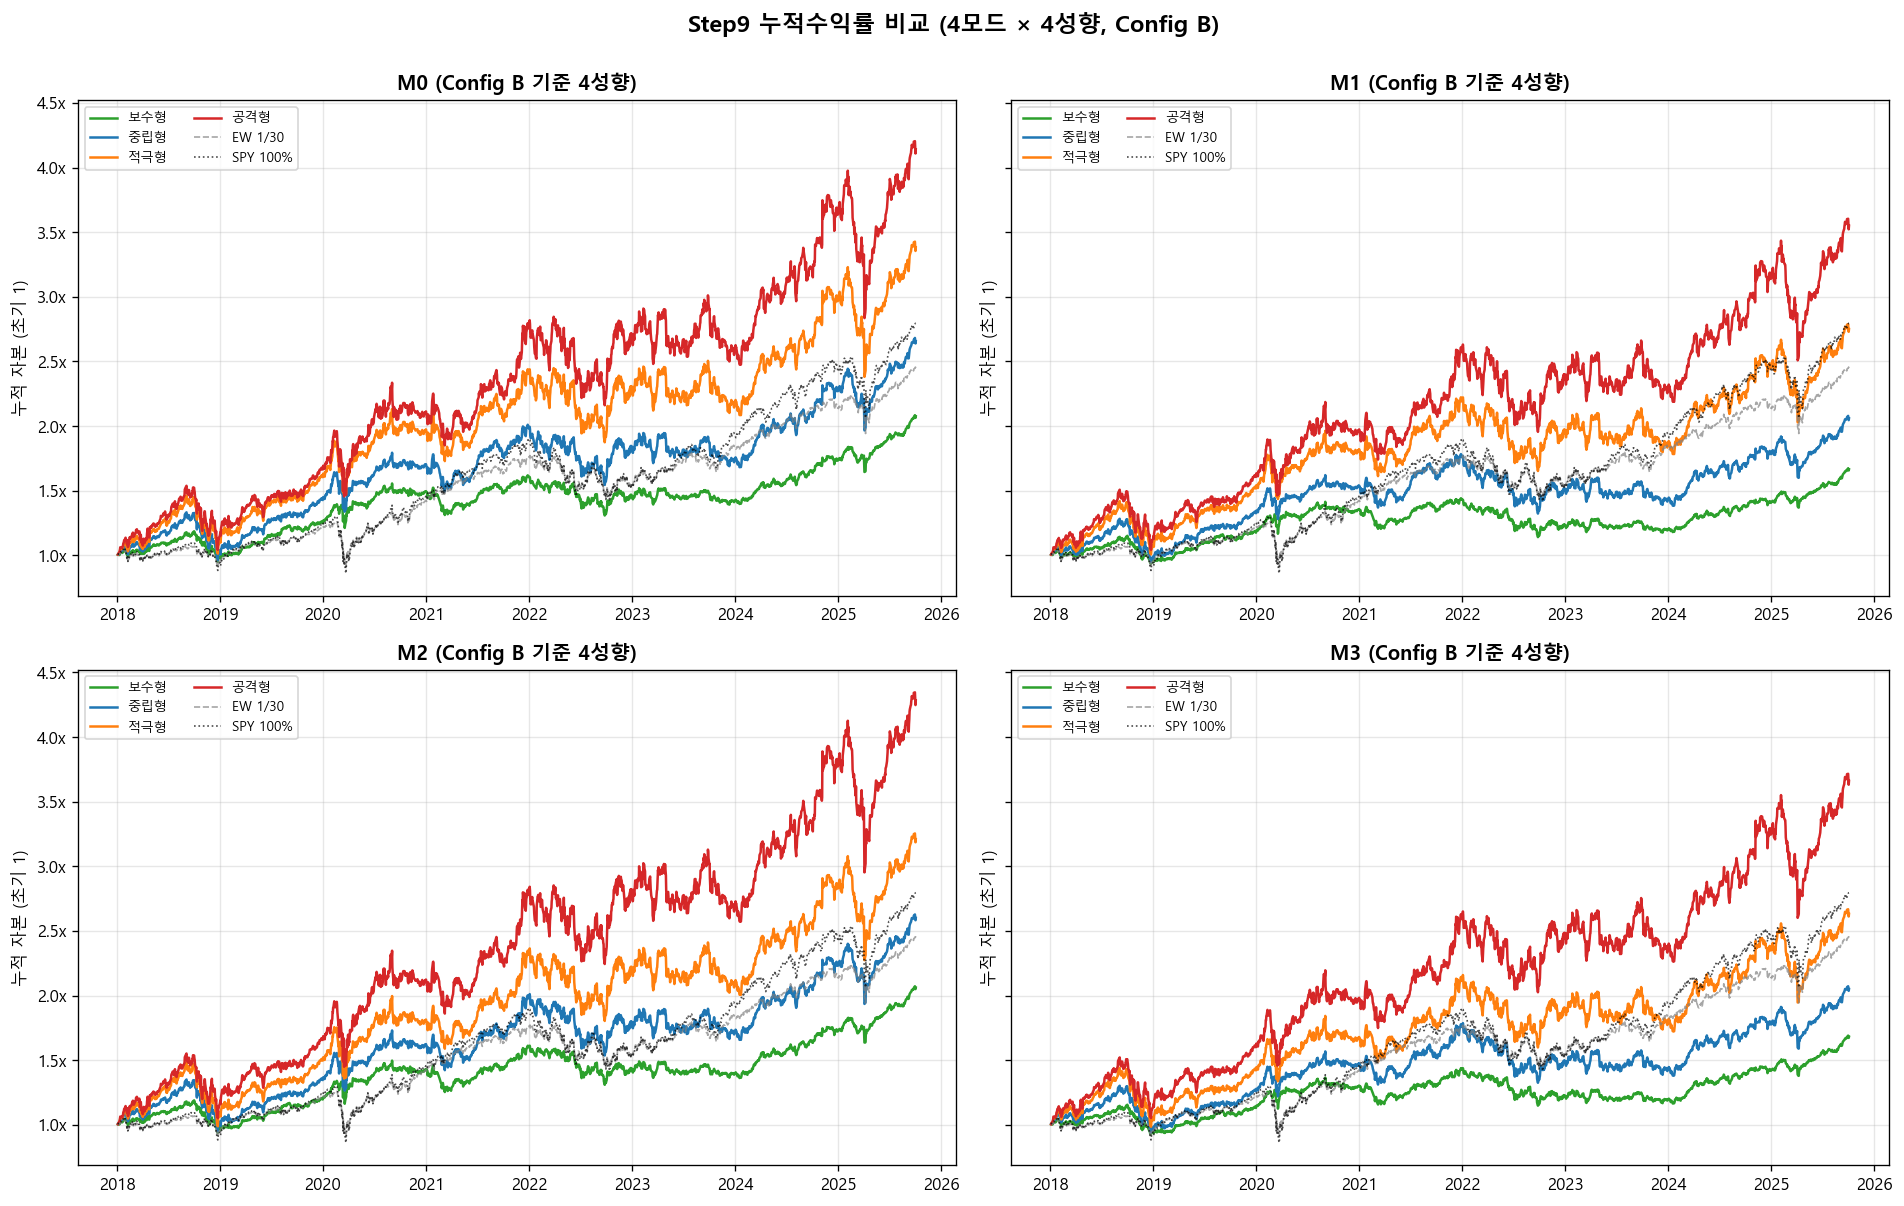

저장: images/step9_01_cumulative.png


In [9]:
# ============================================================
# 시각화 1: 누적수익률 (모드별 4패널, 각 패널 Config B 기준 4성향)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes = axes.flatten()

profile_colors = {'보수형': '#2ca02c', '중립형': '#1f77b4',
                   '적극형': '#ff7f0e', '공격형': '#d62728'}

for idx, mode in enumerate(MODES):
    ax = axes[idx]
    for profile in PROFILES:
        key = f'{mode}_{profile}_ALERT_B'
        if key in results:
            cum = (1 + results[key]).cumprod()
            ax.plot(cum.index, cum.values,
                    color=profile_colors[profile], label=profile, linewidth=1.5)
    # 벤치마크 오버레이
    ax.plot((1 + results['BENCH_EW']).cumprod(),
            color='gray', linestyle='--', linewidth=1.0, label='EW 1/30', alpha=0.7)
    ax.plot((1 + results['BENCH_SPY']).cumprod(),
            color='black', linestyle=':', linewidth=1.0, label='SPY 100%', alpha=0.7)

    ax.set_title(f'{mode} (Config B 기준 4성향)', fontsize=12, fontweight='bold')
    ax.set_ylabel('누적 자본 (초기 1)', fontsize=10)
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}x'))

fig.suptitle('Step9 누적수익률 비교 (4모드 × 4성향, Config B)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
fig.savefig(IMG_DIR / 'step9_01_cumulative.png', bbox_inches='tight')
plt.show()
print('저장: images/step9_01_cumulative.png')


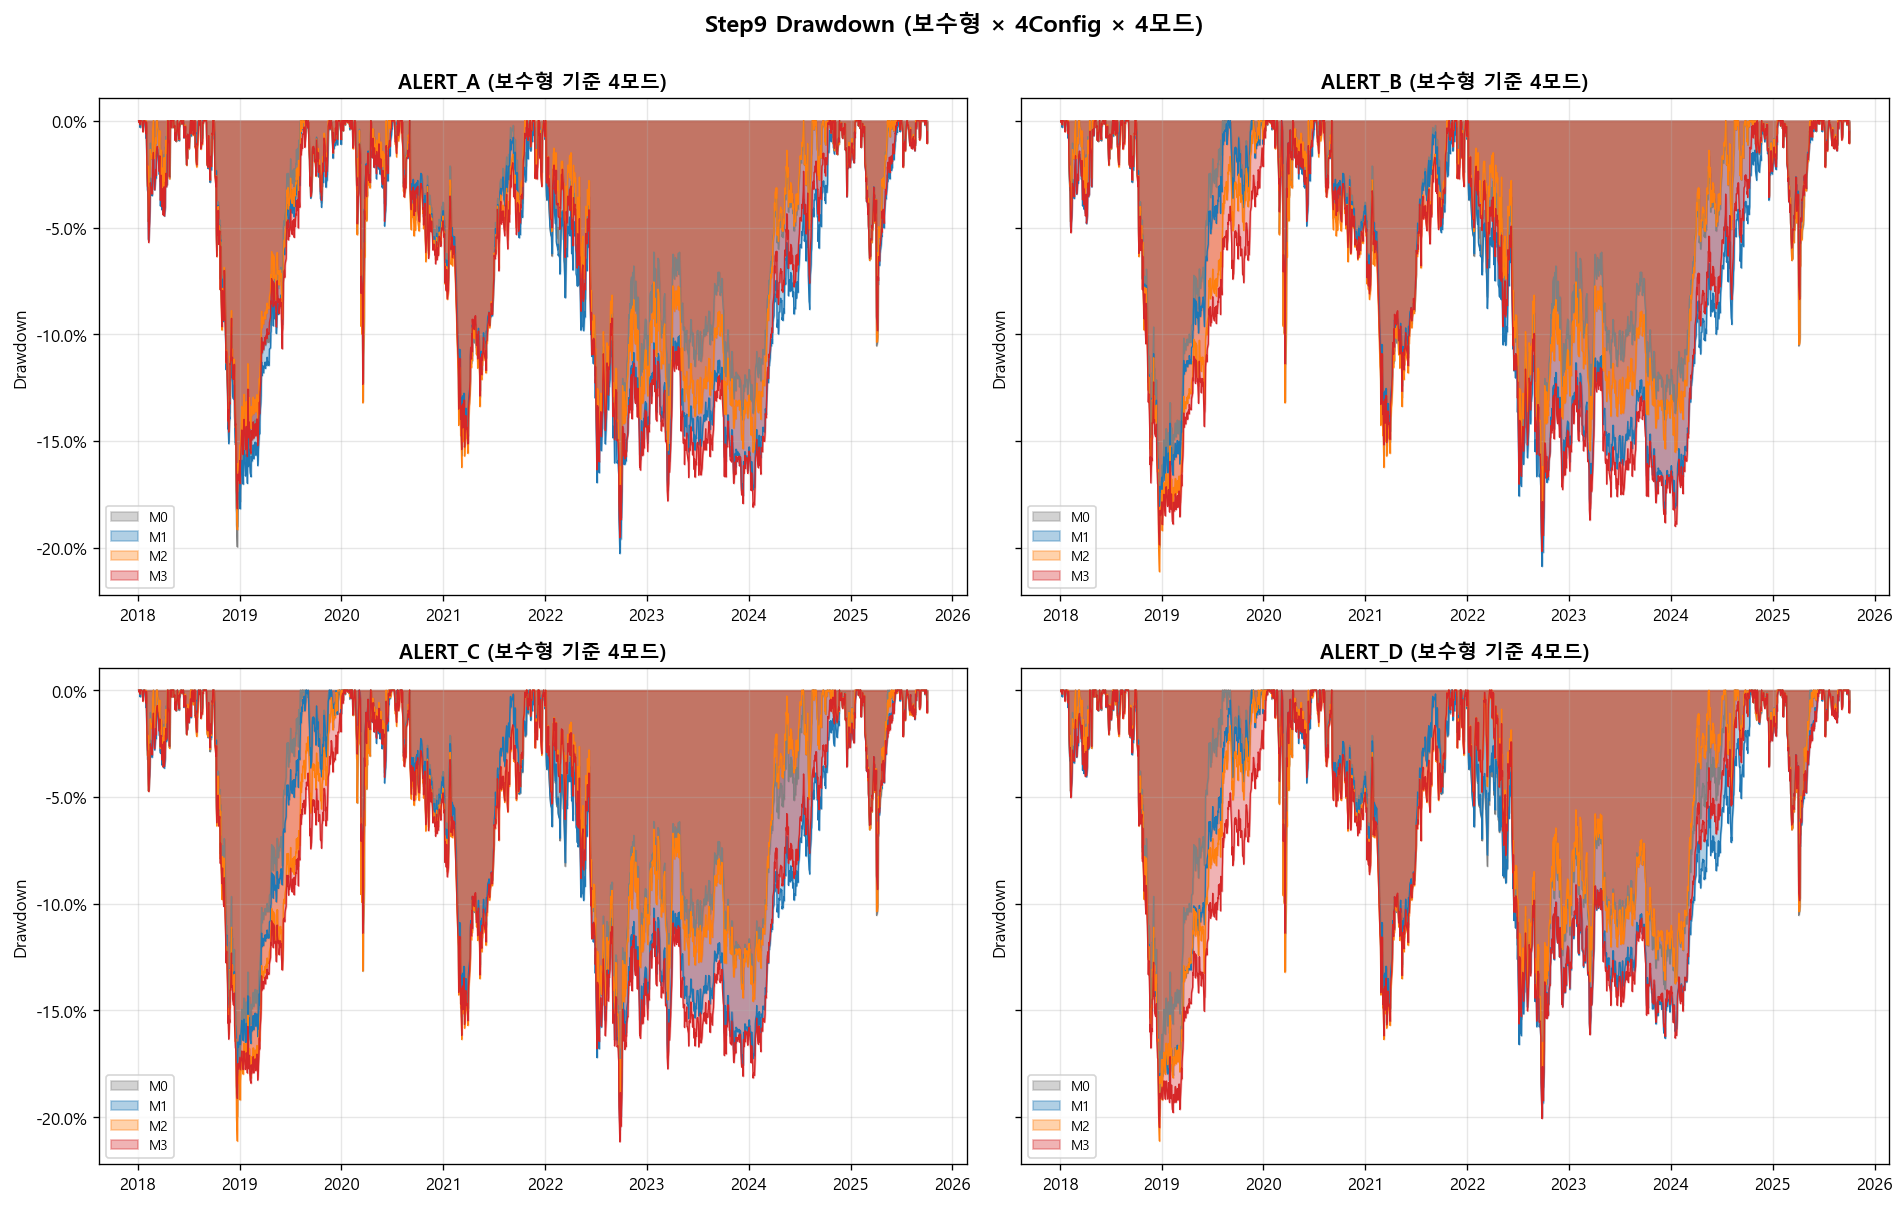

저장: images/step9_02_drawdown.png


In [10]:
# ============================================================
# 시각화 2: Drawdown (보수형 4 Config 기준, 4모드 비교)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes = axes.flatten()

mode_colors = {'M0': '#808080', 'M1': '#1f77b4',
               'M2': '#ff7f0e', 'M3': '#d62728'}

for idx, config in enumerate(CONFIG_NAMES):
    ax = axes[idx]
    for mode in MODES:
        key = f'{mode}_보수형_{config}'
        if key in results:
            cum = (1 + results[key]).cumprod()
            peak = cum.cummax()
            dd = (cum - peak) / peak
            ax.fill_between(dd.index, 0, dd.values,
                            color=mode_colors[mode], alpha=0.35, label=mode)
            ax.plot(dd.index, dd.values, color=mode_colors[mode], linewidth=0.8)

    ax.set_title(f'{config} (보수형 기준 4모드)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Drawdown', fontsize=10)
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle('Step9 Drawdown (보수형 × 4Config × 4모드)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
fig.savefig(IMG_DIR / 'step9_02_drawdown.png', bbox_inches='tight')
plt.show()
print('저장: images/step9_02_drawdown.png')


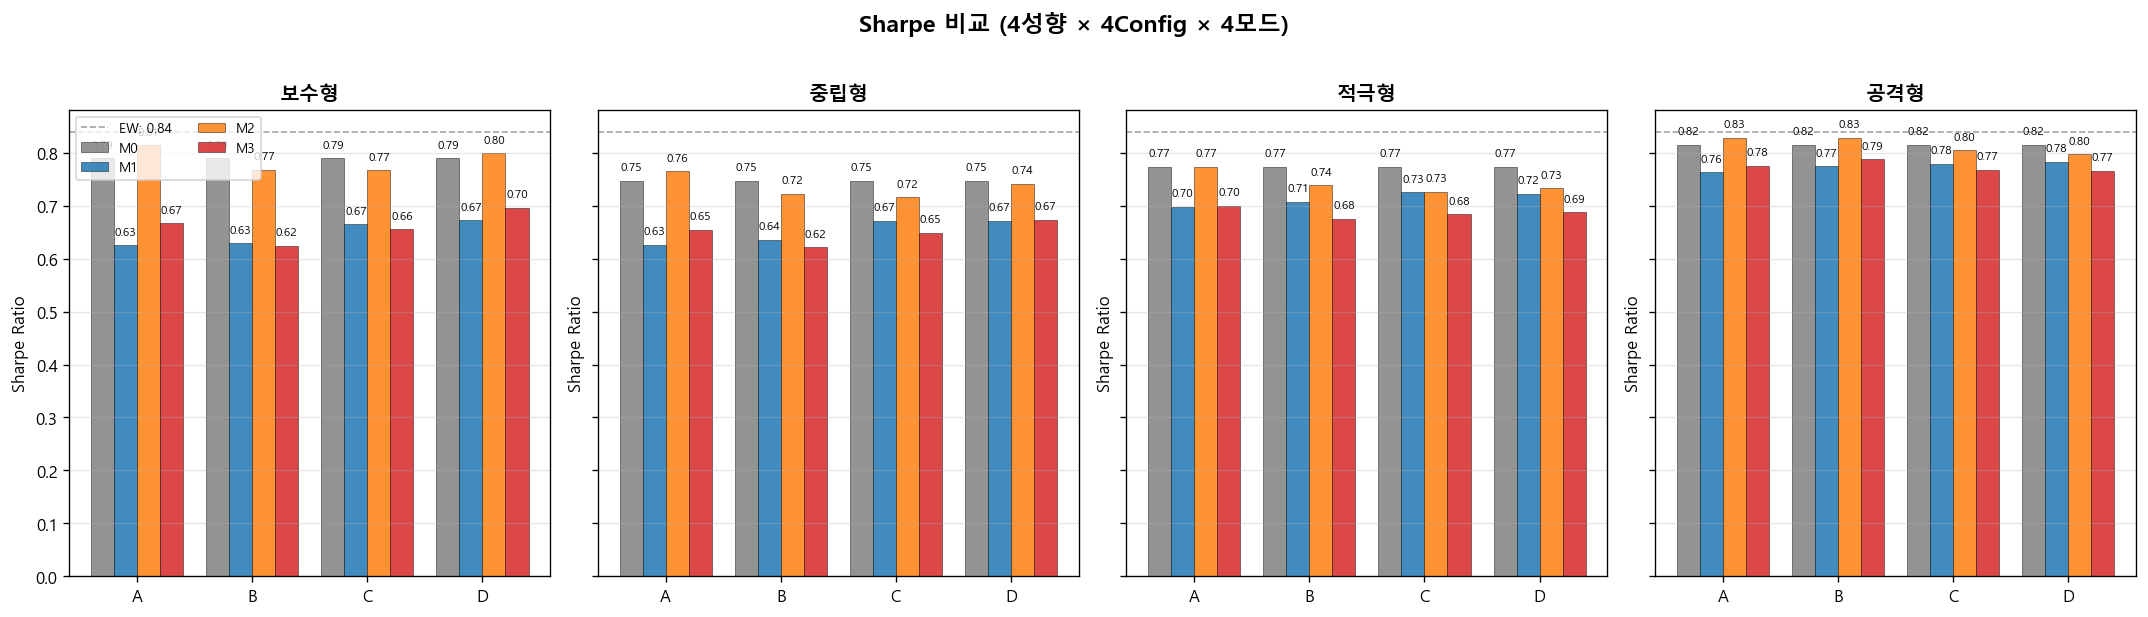

저장: images/step9_03_mode_comparison.png


In [11]:
# ============================================================
# 시각화 3: 성향별 × Config별 × 모드별 Sharpe 바차트
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

for idx, profile in enumerate(PROFILES):
    ax = axes[idx]
    x = np.arange(len(CONFIG_NAMES))
    width = 0.2

    for m_idx, mode in enumerate(MODES):
        sharpes = []
        for config in CONFIG_NAMES:
            key = f'{mode}_{profile}_{config}'
            if key in results:
                sharpes.append(metrics_df.loc[key, 'sharpe'])
            else:
                sharpes.append(0)
        offset = (m_idx - 1.5) * width
        bars = ax.bar(x + offset, sharpes, width=width, label=mode,
                      color=mode_colors[mode], alpha=0.85, edgecolor='black', linewidth=0.3)
        for bar, s in zip(bars, sharpes):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f'{s:.2f}', ha='center', fontsize=7)

    # 벤치마크 기준선
    ew_sharpe = metrics_df.loc['BENCH_EW', 'sharpe']
    ax.axhline(ew_sharpe, color='gray', linestyle='--', linewidth=1, alpha=0.7,
                label=f'EW: {ew_sharpe:.2f}')

    ax.set_xticks(x)
    ax.set_xticklabels([c.replace('ALERT_', '') for c in CONFIG_NAMES], fontsize=10)
    ax.set_title(profile, fontsize=12, fontweight='bold')
    ax.set_ylabel('Sharpe Ratio', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    if idx == 0:
        ax.legend(loc='upper left', fontsize=8, ncol=2)

fig.suptitle('Sharpe 비교 (4성향 × 4Config × 4모드)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(IMG_DIR / 'step9_03_mode_comparison.png', bbox_inches='tight')
plt.show()
print('저장: images/step9_03_mode_comparison.png')


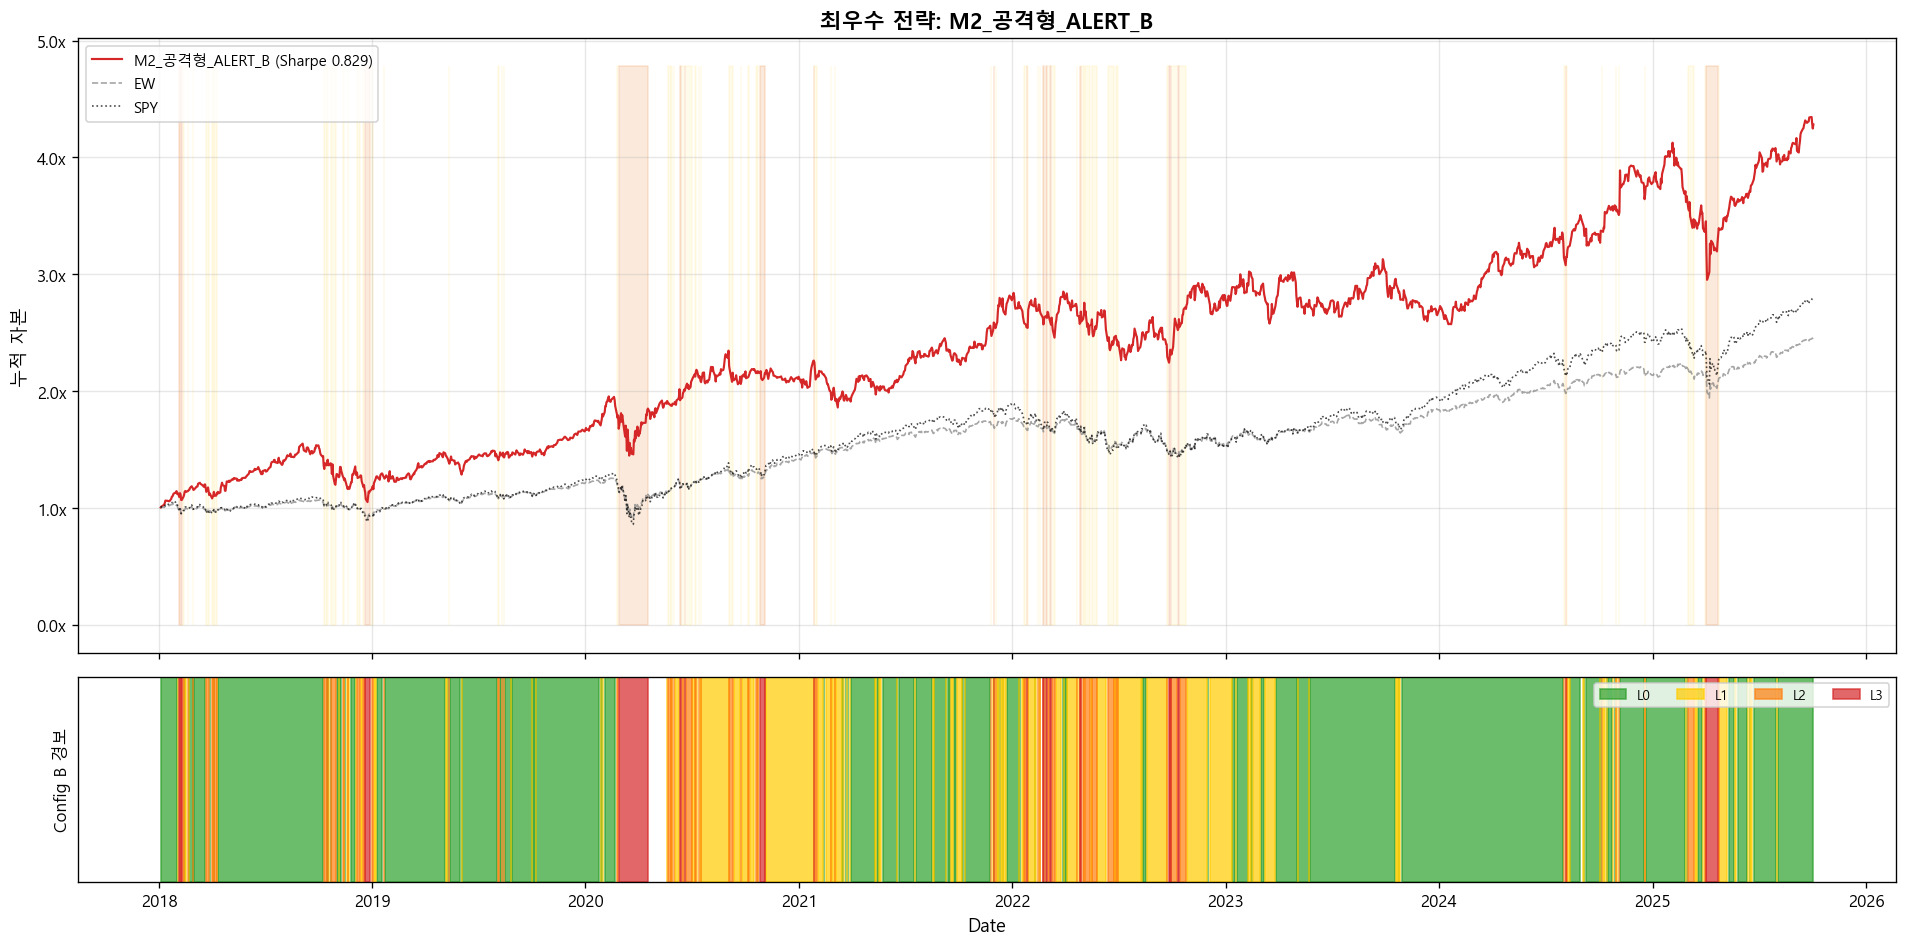

저장: images/step9_04_regime_overlay.png (최우수: M2_공격형_ALERT_B)


In [12]:
# ============================================================
# 시각화 4: 최우수 전략의 수익률 + 레짐/경보 오버레이
# ============================================================

# Sharpe 1위 전략 (벤치마크 제외)
strategy_only = metrics_df[~metrics_df.index.str.startswith('BENCH')]
best_key = strategy_only.index[0]
best_ret = results[best_key]
best_cum = (1 + best_ret).cumprod()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# 상단: 누적수익률
ax1.plot(best_cum.index, best_cum.values, color='#d62728', linewidth=1.3,
         label=f'{best_key} (Sharpe {metrics_df.loc[best_key, "sharpe"]:.3f})')
ax1.plot((1 + results['BENCH_EW']).cumprod(),
         color='gray', linestyle='--', linewidth=1, label='EW', alpha=0.7)
ax1.plot((1 + results['BENCH_SPY']).cumprod(),
         color='black', linestyle=':', linewidth=1, label='SPY', alpha=0.7)

# 경보 레벨 (Config B 기준)
alert_in_range = alerts.loc[best_cum.index[0]:best_cum.index[-1], 'alert_b']
for level, color in [(2, '#ffcc00'), (3, '#d62728')]:
    mask = alert_in_range >= level
    if mask.any():
        ax1.fill_between(alert_in_range.index, 0, best_cum.max()*1.1,
                         where=mask, color=color, alpha=0.08)

ax1.set_ylabel('누적 자본', fontsize=11)
ax1.set_title(f'최우수 전략: {best_key}', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}x'))

# 하단: 경보 타임라인
alert_colors = {0: '#2ca02c', 1: '#ffcc00', 2: '#ff7f0e', 3: '#d62728'}
for level in [0, 1, 2, 3]:
    mask = alert_in_range == level
    if mask.any():
        ax2.fill_between(alert_in_range.index, 0, 1, where=mask,
                         color=alert_colors[level], alpha=0.7,
                         transform=ax2.get_xaxis_transform(),
                         label=f'L{level}')
ax2.set_ylabel('Config B 경보', fontsize=10)
ax2.set_yticks([])
ax2.legend(loc='upper right', fontsize=8, ncol=4)
ax2.set_xlabel('Date', fontsize=11)

plt.tight_layout()
fig.savefig(IMG_DIR / 'step9_04_regime_overlay.png', bbox_inches='tight')
plt.show()
print(f'저장: images/step9_04_regime_overlay.png (최우수: {best_key})')


## 9-6. 산출물 저장


In [13]:
# ============================================================
# 산출물 저장 (pkl + csv)
# ============================================================

# pkl: 전체 일별 수익률 시계열
with open(DATA_DIR / 'step9_backtest_results.pkl', 'wb') as f:
    pickle.dump({
        'results': results,
        'modes': MODES,
        'profiles': PROFILES,
        'configs': CONFIG_NAMES,
        'benchmarks': ['BENCH_EW', 'BENCH_SPY', 'BENCH_60_40'],
        'windows_count': len(windows_cov),
        'total_cost_bps': TOTAL_COST * 10_000,
    }, f)

# csv: 성과 지표 테이블
metrics_df.to_csv(DATA_DIR / 'step9_metrics.csv')

pkl_size = os.path.getsize(DATA_DIR / 'step9_backtest_results.pkl') / 1024
csv_size = os.path.getsize(DATA_DIR / 'step9_metrics.csv') / 1024

print('=' * 60)
print('Step 9 저장 완료')
print('=' * 60)
print(f'  step9_backtest_results.pkl : {pkl_size:7.1f} KB ({len(results)}개 전략)')
print(f'  step9_metrics.csv          : {csv_size:7.1f} KB ({len(metrics_df)}행)')
print()
print('Step 10에서 다음 분석 가능:')
print('  - 경로 기여도 분해 (M1-M0, M2-M0, M3-M0, M3-M1)')
print('  - Bootstrap Sharpe 차이 검정')
print('  - Bonferroni + FDR 다중 비교 보정')
print('  - IR 및 ΔSR 실무 기준 유의성 평가')
print('  - 스트레스 시나리오 11개 + 64 cell Ablation Heatmap')
print('  - Fallback 타입별 성과 비교')


Step 9 저장 완료
  step9_backtest_results.pkl :  2887.7 KB (67개 전략)
  step9_metrics.csv          :    11.7 KB (67행)

Step 10에서 다음 분석 가능:
  - 경로 기여도 분해 (M1-M0, M2-M0, M3-M0, M3-M1)
  - Bootstrap Sharpe 차이 검정
  - Bonferroni + FDR 다중 비교 보정
  - IR 및 ΔSR 실무 기준 유의성 평가
  - 스트레스 시나리오 11개 + 64 cell Ablation Heatmap
  - Fallback 타입별 성과 비교


---
## 9-X. 버전 스냅샷 + ΔSharpe 차분 표 (자동)

각 재실행 시 `step9_metrics_snapshots/<timestamp>.csv`로 스냅샷 저장.
이전 가장 최근 스냅샷과 현재 결과를 strategy 단위로 join하여 ΔSharpe 표 자동 출력.
- 회귀 검증: 코드 수정 없이 재실행했는데 ΔSharpe ≠ 0이면 재현성 문제
- 영향 검증: Sahm 제거·alert_lag 변경 등 의도된 수정 후 ΔSharpe 분포 확인


In [14]:
# ============================================================
# 9-X. 버전 스냅샷 + ΔSharpe 자동 비교 (Task 13/v4.2d)
# ============================================================
import datetime, glob, pathlib

SNAP_DIR = DATA_DIR / 'step9_metrics_snapshots'
SNAP_DIR.mkdir(exist_ok=True)
ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
cur_path = SNAP_DIR / f'{ts}.csv'
metrics_df.to_csv(cur_path)
print(f'snapshot saved: {cur_path.name}  ({len(metrics_df)} rows)')

prev_files = sorted(glob.glob(str(SNAP_DIR / '*.csv')))
prev_files = [p for p in prev_files if pathlib.Path(p).name != cur_path.name]
if not prev_files:
    print('직전 스냅샷이 없음 — ΔSharpe 비교 생략 (다음 재실행부터 비교 표 출력)')
else:
    prev_path = prev_files[-1]
    prev_df = pd.read_csv(prev_path, index_col=0)
    cur_df = pd.read_csv(cur_path, index_col=0)
    if 'strategy' not in prev_df.columns:
        prev_df = prev_df.reset_index().rename(columns={'index': 'strategy'})
    if 'strategy' not in cur_df.columns:
        cur_df = cur_df.reset_index().rename(columns={'index': 'strategy'})
    merged = prev_df[['strategy', 'sharpe']].merge(
        cur_df[['strategy', 'sharpe']], on='strategy', how='outer',
        suffixes=('_prev', '_cur'))
    merged['delta_sharpe'] = merged['sharpe_cur'] - merged['sharpe_prev']
    merged_sorted = merged.reindex(merged['delta_sharpe'].abs().sort_values(ascending=False).index)
    print(f'=== ΔSharpe 비교 (vs {pathlib.Path(prev_path).name}) ===')
    print(f'직전 스냅샷 strategies: {len(prev_df):3d} | 현재: {len(cur_df):3d} | 공통: {merged.dropna().shape[0]:3d}')
    print(f'  |Δ| >= 0.10 : {(merged.delta_sharpe.abs() >= 0.10).sum():3d}')
    print(f'  |Δ| >= 0.05 : {(merged.delta_sharpe.abs() >= 0.05).sum():3d}')
    print(f'  |Δ| >= 0.01 : {(merged.delta_sharpe.abs() >= 0.01).sum():3d}')
    print('  Top 10 |ΔSharpe|:')
    print(merged_sorted.head(10).to_string(index=False))


snapshot saved: 20260419_144219.csv  (67 rows)
=== ΔSharpe 비교 (vs 20260419_143912.csv) ===
직전 스냅샷 strategies:  67 | 현재:  67 | 공통:  67
  |Δ| >= 0.10 :   0
  |Δ| >= 0.05 :   0
  |Δ| >= 0.01 :   0
  Top 10 |ΔSharpe|:
      strategy  sharpe_prev  sharpe_cur  delta_sharpe
   BENCH_60_40     0.814450    0.814450           0.0
      BENCH_EW     0.838766    0.838766           0.0
     BENCH_SPY     0.775794    0.775794           0.0
M0_공격형_ALERT_A     0.815090    0.815090           0.0
M0_공격형_ALERT_B     0.815090    0.815090           0.0
M0_공격형_ALERT_C     0.815090    0.815090           0.0
M0_공격형_ALERT_D     0.815090    0.815090           0.0
M0_보수형_ALERT_A     0.789414    0.789414           0.0
M0_보수형_ALERT_B     0.789414    0.789414           0.0
M0_보수형_ALERT_C     0.789414    0.789414           0.0
